In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd
from functools import lru_cache

from multiprocessing import Pool


In [4]:
@lru_cache(maxsize=None)
def mod_inv(a, m):
    m0, x0, x1 = m, 0, 1
    while a > 1:
        q = a // m
        m, a = a % m, m
        x0, x1 = x1 - q * x0, x0
    return x1 + m0 if x1 < 0 else x1

def hofstadter_band(p:int,q:int):
    if gcd(p,q) != 1:
        raise ValueError("p and q must be coprime.")
    sep = 100
    kx = np.linspace(-np.pi, np.pi, sep)
    ky = np.linspace(-np.pi/q, np.pi/q, sep)
    H = np.zeros((sep, sep, q, q), dtype=complex)
    for m in range(q):
        H[...,m,m] = 2*np.cos(ky[:,None] + 2*np.pi*m*p/q)
        H[...,m,(m+1)%q] = np.exp(-1j*kx[None,:])
        H[..., (m+1)%q,m] = np.exp(1j*kx[None,:])
    band = np.linalg.eigvalsh(H)
    bandtop = np.max(band, axis=(0,1))
    bandbottom = np.min(band, axis=(0,1))
    return bandtop, bandbottom

def coprime_pairs(n):
    '''
    Generate all coprime pairs (p,q) such that 1 <= p < q <= n and q is a factor of n.
    '''
    for q in range(1, n+1):
        for p in range(1, q):
            if gcd(p, q) == 1:
                yield (p, q)



def compute_cherns(mu, bandtop, bandbottom, p, q):
    M = len(mu)
    r = np.sum(bandtop < mu[:, None], axis=1)   # 填充的能带数

    mask_lower = (r == 0) & (mu < bandbottom[0])
    mask_upper = (r == q) & (mu > bandtop[-1])

    mid_mask = (r > 0) & (r < q)
    mask_inner = np.zeros(M, dtype=bool)
    if np.any(mid_mask):
        r_mid = r[mid_mask]
        top_low = bandtop[r_mid - 1]
        bot_high = bandbottom[r_mid]
        gap_open = top_low < bot_high
        in_gap = (top_low < mu[mid_mask]) & (mu[mid_mask] < bot_high)
        mask_inner[mid_mask] = gap_open & in_gap

    inv_p = mod_inv(p, q) 
    half = q // 2
    j = np.arange(1, q) 
    t = (inv_p * j) % q
    t[t > half] -= q
    k_for_r = np.zeros(q + 1, dtype=int)
    k_for_r[1:q] = t 
    chern = np.full(M, 999, dtype=int)
    chern[mask_lower] = 0
    chern[mask_upper] = 0
    chern[mask_inner] = k_for_r[r[mask_inner]]
    return chern



q_max = 40
pairs = list(coprime_pairs(q_max))
pairs.sort(key=lambda x: x[0]/x[1])  # Sort by p/q ratio
mu = np.linspace(-4, 4, 1000)
chern_numbers = np.zeros((len(pairs), len(mu)), dtype=int)

def helper(p,q):
    bandtop, bandbottom = hofstadter_band(p, q)
    return compute_cherns(mu, bandtop, bandbottom, p, q)

with Pool(12) as pool:
    results = pool.starmap(helper, pairs)
cherns = np.array(results,dtype=int)  
chern_numbers = np.where(cherns == 999, np.nan, cherns)  # Replace 999 with NaN for plotting

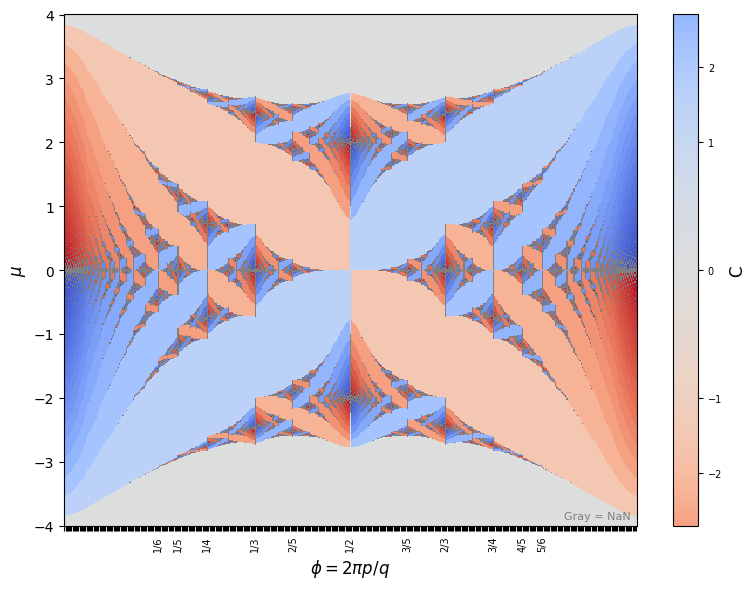

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ============================================
# 1. 数据准备
# ============================================
chern_numbers = chern_numbers.astype(float)

valid = chern_numbers[~np.isnan(chern_numbers)]
if len(valid) == 0:
    raise ValueError("全部 Chern 数都是 NaN，无法绘图")

cmin = int(np.nanmin(chern_numbers))
cmax = int(np.nanmax(chern_numbers))
max_abs = max(abs(cmin), abs(cmax))
vmax_trans = np.log1p(max_abs)

# ============================================
# 2. 对数非线性归一化
# ============================================
def forward(c):
    return np.sign(c) * np.log1p(np.abs(c))

class LogNorm(Normalize):
    def __init__(self, vmin, vmax, clip=False):
        super().__init__(vmin, vmax, clip)
    def __call__(self, value, clip=None):
        result = np.ma.masked_invalid(forward(value))
        return super().__call__(result, clip)

norm = LogNorm(vmin=-vmax_trans, vmax=vmax_trans)

# ============================================
# 3. 色彩表：浅蓝→深蓝→白→深红→浅红
# ============================================
cmap = plt.cm.coolwarm_r
cmap.set_bad(color='gray')

# ============================================
# 4. 构建坐标（横轴 φ=p/q，纵轴 μ）
# ============================================
dmu = mu[1] - mu[0]
mu_edges = np.concatenate([mu - dmu/2, [mu[-1] + dmu/2]])
x_edges = np.arange(len(pairs) + 1) - 0.5
y_edges = mu_edges

# 转置数据以匹配 (纵轴点数, 横轴点数)
C = chern_numbers.T

# ============================================
# 5. 绘图
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_edges, y_edges, C,
                     cmap=cmap, norm=norm, shading='flat')

ax.set_xlabel(r'$\phi = 2\pi p/q$', fontsize=12)
ax.set_ylabel(r'$\mu$', fontsize=12)

# x 轴刻度：只标注 q < 7 的分数
xtick_positions = np.arange(len(pairs))
xtick_labels = [f'{p}/{q}' if q < 7 else '' for p, q in pairs]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=90, fontsize=7)

# ============================================
# 6. Colorbar：显示所有存在的整数刻度（保证有 2,3,4）
# ============================================
cbar_ticks = np.arange(cmin, cmax + 1)   # 完整整数序列

# 如果刻度太多（比如超过 30 个），可以缩小字体或旋转标签
cbar = plt.colorbar(mesh, ticks=cbar_ticks)
cbar.set_label('C', fontsize=12)
cbar.ax.tick_params(labelsize=7)        # 略微调小刻度标签字体

ax.text(0.99, 0.01, 'Gray = NaN', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('Chern_numbers.pdf')